#Project 2 - CA COVID-19 Vaccine Data

Today's project is inspired by the graphics in this article in the LA Time about COVID-19 vaccinations in California. This notebook analyzes California vaccine progress over time and compares people who received at least one dose with people who were fully vaccinated.

Note: This dataset was downloaded on May 10, 2021 so some of the data will be different than the news by the time you do your project. If you would like to download the latest dataset, you can visit https://data.ca.gov/dataset/covid-19-vaccine-progress-dashboard-data and download the "Statewide COVID-19 Vaccines Administered By County" csv file.



## Step 1: Import libraries

We will use `pandas` for data handling, `numpy` for numeric helpers, and `matplotlib` for plotting.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Step 2: Load the data

This loading section assumes you have uploaded the file with the name 'covid-19-progress-county-051021.csv' to your google drive in these specific folders ColabNotebooks/scip_data/chapter2.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

covid_data = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/SCIP2026/UPDATED CURRICULUM/Python Track/Python2026/scip_data/chapter4/covid-19-progress-county-051021.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Quick data check

It helps to verify the shape, columns, and first few rows before analyzing the data.

In [ ]:
print('Shape:', covid_data.shape)
print('Columns:', list(covid_data.columns))
display(covid_data.head())

## Step 3: Clean up text fields

Remove extra spaces and standardize text columns so filters work correctly.

In [ ]:
# Remove leading/trailing whitespace from all column names.
covid_data.columns = covid_data.columns.astype(str).str.strip()

# Remove leading/trailing whitespace from county names.
if 'county' in covid_data.columns:
    covid_data['county'] = covid_data['county'].astype(str).str.strip()

## Step 4: Parse dates

Convert `administered_date` to datetime so the plots appear in the correct order.

In [ ]:
if 'administered_date' in covid_data.columns:
    covid_data['administered_date'] = pd.to_datetime(
        covid_data['administered_date'], errors='coerce'
    )

# Remove rows with invalid dates.
covid_data = covid_data.dropna(subset=['administered_date'])

## Step 5: Focus on California statewide data

The statewide row is stored under `All CA Counties`.


In [ ]:
covid_ca = covid_data.loc[covid_data['county'] == 'All CA Counties'].copy()

# California population used in the assignment.
ca_pop = 39_466_917

# Sort by date so plots render correctly.
covid_ca = covid_ca.sort_values('administered_date').reset_index(drop=True)

# Create percentage columns.
covid_ca['partial_percent'] = (
    covid_ca['cumulative_at_least_one_dose'] / ca_pop * 100
).round(2)

covid_ca['fully_percent'] = (
    covid_ca['cumulative_fully_vaccinated'] / ca_pop * 100
).round(2)

display(covid_ca[['administered_date', 'partial_percent', 'fully_percent']].head())



## Step 6: Plot 1 — Partial vs. fully vaccinated percentages

This chart compares the share of residents with at least one dose and the share who were fully vaccinated.

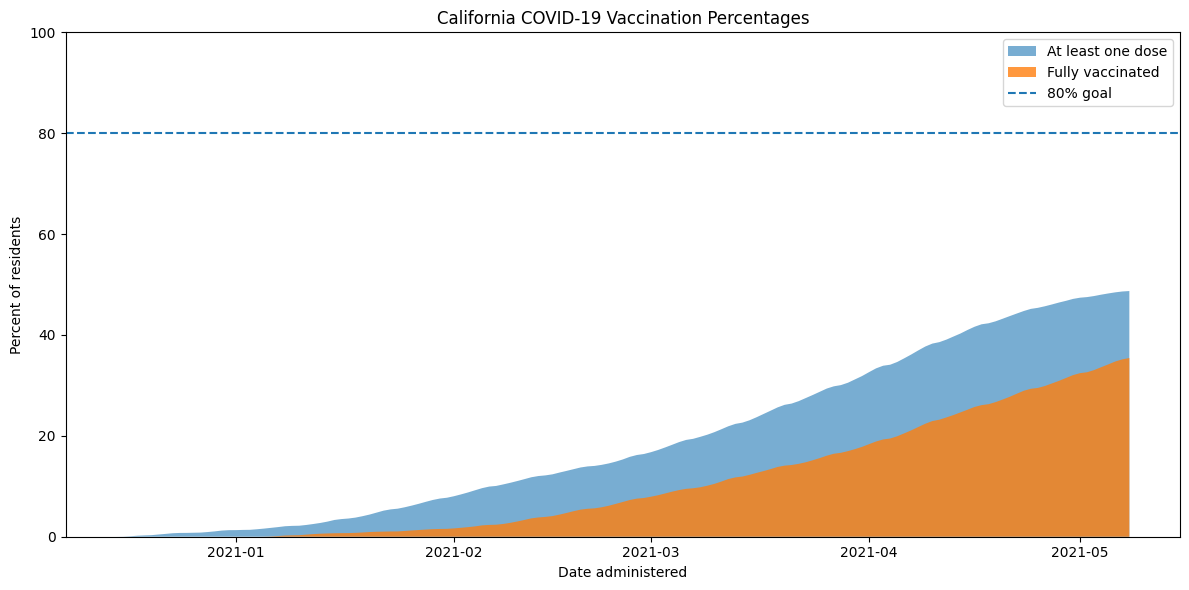

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(
    covid_ca['administered_date'],
    covid_ca['partial_percent'],
    label='At least one dose',
    alpha=0.55,
)
ax.fill_between(
    covid_ca['administered_date'],
    covid_ca['fully_percent'],
    label='Fully vaccinated',
    alpha=0.8,
)

ax.set_title('California COVID-19 Vaccination Percentages')
ax.set_xlabel('Date administered')
ax.set_ylabel('Percent of residents (%)')
ax.set_ylim(0, 100)
ax.axhline(80, linestyle='--', linewidth=1.5, label='80% goal')
ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()


## Step 7: Plot 2 — Daily doses plus 7-day rolling average

A rolling average makes the trend easier to read than daily changes alone.

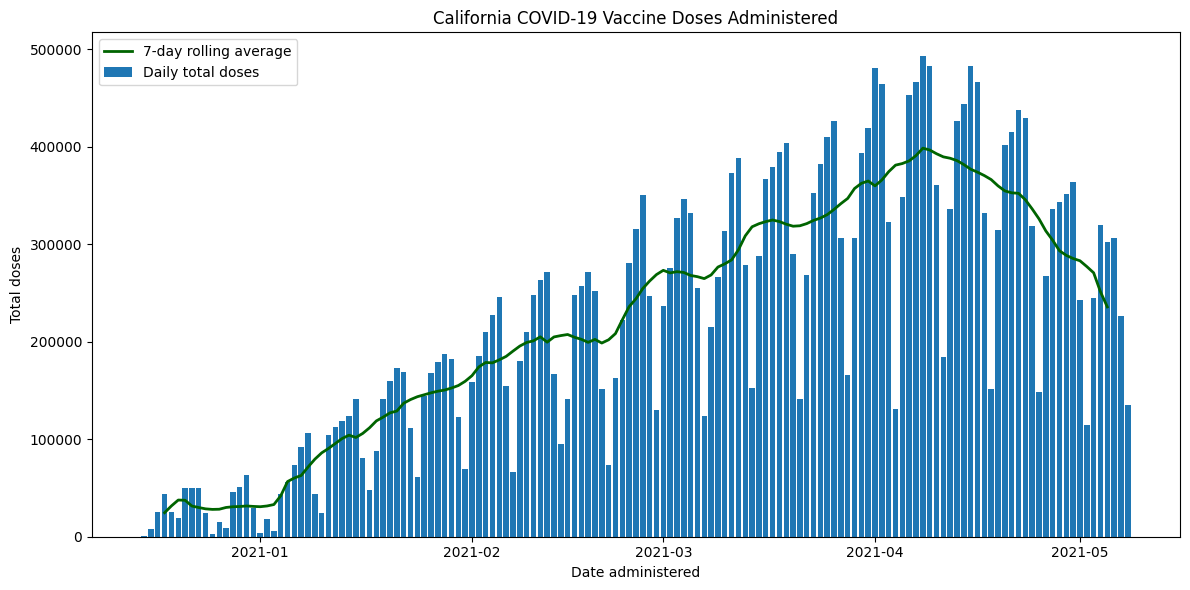

In [ ]:
covid_ca['wk_avg'] = (
    covid_ca['total_doses']
    .rolling(window=7, center=True)
    .mean()
    .round(0)
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    covid_ca['administered_date'],
    covid_ca['total_doses'],
    label='Daily total doses',
    linewidth=1,
    alpha=0.5,
)
ax.plot(
    covid_ca['administered_date'],
    covid_ca['wk_avg'],
    label='7-day rolling average',
    linewidth=2.5,
)

ax.set_title('California COVID-19 Vaccine Doses Administered')
ax.set_xlabel('Date administered')
ax.set_ylabel('Total doses')
ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

#YOUR TURN

County version: choose one county and repeat the same workflow

Optional: Share your result with your team.